In [1]:
for i in range(10):
    i

In [2]:

import pySPM
print(pySPM.__version__)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

import os
from IPython import display
I = pySPM.ITM('LiNbO3_position 3_2 BA positive depth.itm')

0.6.2


/home/cbed/hannes/Dataanalysis_Tof_SIMs/henv/lib/python3.10/site-packages/pySPM/ITM.py:149: UserWarning: Failed to get sf,k0, find alternative
  self.sf, self.k0 = self.get_mass_cal()


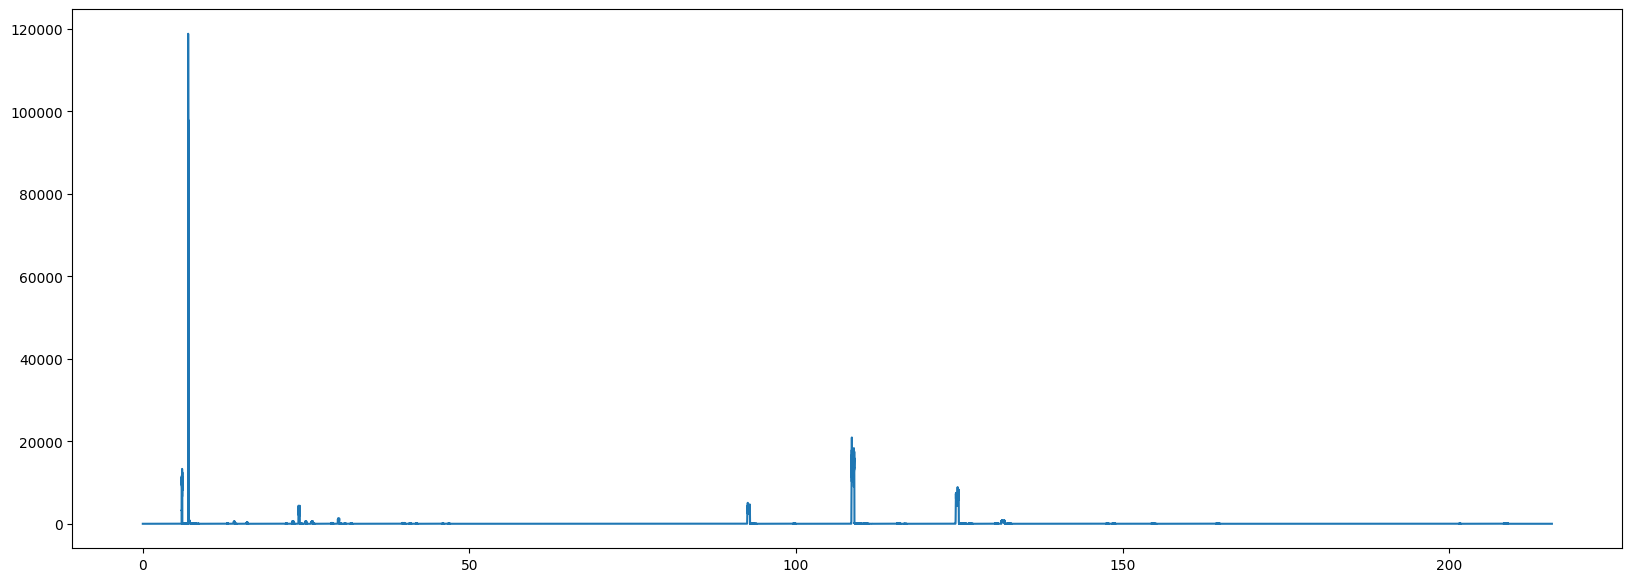

In [3]:
from IPython import display
masses, raw_spectrum = I.get_raw_spectrum(scans=range(2000), prog=True) # get raw spectrum of the first 10 scans
display.clear_output()

fig = plt.figure(figsize=(20,7))
plt.plot(masses, raw_spectrum)

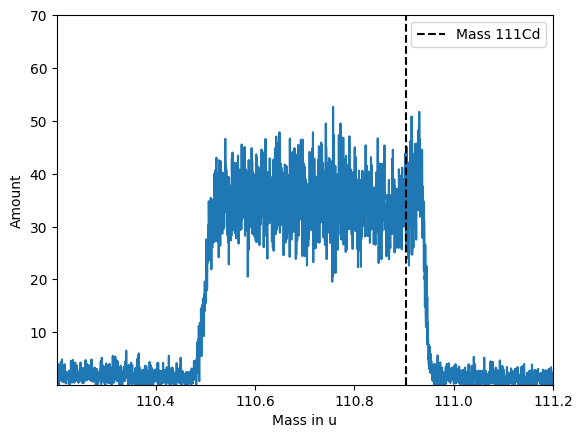

In [11]:
fig, ax = plt.subplots()
#pySPM.utils.showPeak(masses, raw_spectrum,'Nb', 1.0, ax=ax, polarity='+');
ax.plot(masses, raw_spectrum);
m = 110.7 + 0
a = m - 0.5+0.001
b = m + 0.5
ax.set_xlim(a, b)
ax.set_ylim(.10,70)
ax.set_xlabel('Mass in u')
ax.set_ylabel('Amount')
ax.axvline(110.904, color='black', linestyle='--', label = 'Mass 111Cd')
ax.legend()
# change the plot so it can be published in a paper




In [5]:
def reconstruct(channels, scans=None, sf=None, k0=None, prog=False, time=False
    ):
        """
        Reconstruct an Image from a raw spectra by defining the lower and upper mass
        channels: list of (lower_mass, upper_mass)
        upper_mass: upper mass of the peak
        scans: The list of the scans to take into account (if None, all scans are taken)
        sf/k0: mass calibration. If none take the saved values
        time: If true the upper/lower_mass will be understood as time value
        prog: If True display a progressbar with tqdm
        """
        from pySPM.utils import mass2time

        assert hasattr(channels, "__iter__")
        if not hasattr(channels[0], "__iter__"):
            channels = [channels]
        for c in channels:
            assert len(c) == 2
        if scans is None:
            scans = range(I.Nscan)
        left = np.array([x[0] for x in channels])
        right = np.array([x[1] for x in channels])
        if not time:
            if sf is None or k0 is None:
                sf, k0 = I.get_mass_cal()
            left = mass2time(left, sf=sf, k0=k0)
            right = mass2time(right, sf=sf, k0=k0)
        Counts = [
            np.zeros((I.size["pixels"]["x"], I.size["pixels"]["y"]))
            for x in channels
        ]
        for s in scans:
            Data = I.get_raw_data(s)
            for xy in Data:
                for i, _ch in enumerate(channels):
                    Counts[i][xy[1], xy[0]] += np.sum(
                        (Data[xy] >= left[i]) * (Data[xy] <= right[i])
                    )
        return Counts

In [6]:
d = 6140
save_a = reconstruct([(6, 7)], scans=range(d, d + 10), prog=True)

/tmp/ipykernel_1423431/1731358267.py:25: UserWarning: Failed to get sf,k0, find alternative
  sf, k0 = I.get_mass_cal()


AssertionError: 

In [10]:
upper_energy = 6
lower_energy = 6
start = 1000
end = 3010
stepsize = 10
save_a = [[]for i in range (start, end, stepsize)]
print(save_a)
for i in range(start, end, stepsize):
    # in case of crash 
    save_a[i] = reconstruct([(lower_energy, upper_energy)], scans=range(i, i+stepsize), prog=True)

# save the data
np.save('Cadmium_stepsize'+ str(stepsize)+'.npy', save_a)


[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]


/tmp/ipykernel_1325127/1731358267.py:25: UserWarning: Failed to get sf,k0, find alternative
  sf, k0 = I.get_mass_cal()


IndexError: list assignment index out of range

In [ ]:
# this code evaluates the data singledly and saves the data in bunches 
stepsize = 10
# save the data every 10 scans
def rowup(lower_energy, upper_energy, Element):
    def func(start, end):
        save = [[]for i in range (start, end)]
        for i in range(0, end-start):
            save[i] = reconstruct([(lower_energy, upper_energy)], scans=range(start+i, start+i+1), prog=True)
        print(start, end)
        return save


    for k in range(613):
        save_a = np.array(func(k*stepsize, (k+1)*stepsize))
        position = str(k*stepsize + 10000)[1:]
        # check if folder exists
        if not os.path.exists(Element+ str(stepsize)):
            os.makedirs(Element+ str(stepsize))
        np.save(Element+str(stepsize)+'/'+ Element + position+'.npy', save_a)


# lower_energy = [110.75, 6.98, 92.7,  38.85, 45.7, 22.9]
# higher_energy = [111.15, 7.06,  93.1, 39.1, 46.2,  23.10]
# Element = ['Cd', 'Li', 'Nb','K', 'Li_2O_2', 'Na', 'Na']
# # lower_energy = [126.75, 51.75, 23.9, 208.75, 15.925]
# # higher_energy = [127.15, 52.2, 24.1, 209.25, 16.075]
# # Element = ['CdO', 'Cr', 'Mg', 'Bi', 'O']

# lower_energy = [115.75, 115.75 +16, 127, 108.8]
# higher_energy = [116.15, 132.15, 127.8, 109]
# Element = ['NbLiO', 'NbLiO2', 'CdO', 'NbO']
# for 2024 measurement energy 
# lower_energy = [110.75, 110.95, 6.98,7.02, 92.7, 92.95, 38.85, 45.7, 22.9, 23.02,110.75, 6.98, 92.7, 22.9, 126.75, 51.75,   23.9, 208.75, 15.925, 115.75, 115.75 +16, 127, 108.8]
# higher_energy = [110.95, 111.15, 7.02, 7.06, 92.95, 93.1, 39.1, 46.2, 23.02, 23.10,111.15, 7.06,  93.1,  23.10,127.15, 52.2, 24.1, 209.25, 16.075, 116.15, 132.15, 127.8, 109]
# Element = ['Cdl', 'Cdu', 'Lil', 'Liu', 'Nbl', 'Nbu',      'K', 'Li_2O_2', 'Nal', 'Nau','Cd', 'Li', 'Nb', 'Na', 'CdO', 'Cr', 'Mg', 'Bi', 'O','NbLiO', 'NbLiO2', 'CdO', 'NbO']
# for 2501msm 
lower_energy = [110.5, 110.7, 6.925,7.0, 92.5, 92.75, 38.75, 45.7, 22.8, 22.95,110.5, 6.92, 92.5, 22.8, 126.4, 51.75,   23.7, 208.25, 15.825, 115.5, 115 +16, 126.7, 108.5]
higher_energy = [110.7, 111.0, 7.0, 7.06, 92.75, 93.0, 39.1, 46.2, 22.95, 23.15,111, 7.06,  93.0,  23.15,127.15, 52.2, 24.1, 209.0, 16.075, 116.0, 132.0, 127.5, 109]
Element = ['Cdl', 'Cdu', 'Lil', 'Liu', 'Nbl', 'Nbu',      'K', 'Li_2O_2', 'Nal', 'Nau','Cd', 'Li', 'Nb', 'Na', 'CdO', 'Cr', 'Mg', 'Bi', 'O','NbLiO', 'NbLiO2', 'CdO', 'NbO']


print(len(lower_energy))
print(len(higher_energy))
print(len(Element))


for i in range(len(lower_energy)):
    i = i
    rowup(lower_energy[i], higher_energy[i], Element[i])

23
23
23
590 600
600 610
610 620
620 630
630 640
640 650
650 660
660 670
670 680
680 690
690 700
700 710
710 720
720 730
730 740
740 750
750 760
760 770
770 780
780 790
790 800
800 810
810 820
820 830
830 840
840 850
850 860
860 870
870 880
880 890
890 900
900 910
910 920
920 930
930 940
940 950
950 960
960 970
970 980
980 990
990 1000
1000 1010
1010 1020
1020 1030
1030 1040
1040 1050
1050 1060
1060 1070
1070 1080
1080 1090
1090 1100
1100 1110
1110 1120
1120 1130
1130 1140
1140 1150
1150 1160
1160 1170
1170 1180
1180 1190
1190 1200
1200 1210
1210 1220
1220 1230
1230 1240
1240 1250
1250 1260
1260 1270
1270 1280
1280 1290
1290 1300
1300 1310
1310 1320
1320 1330
1330 1340
1340 1350
1350 1360
1360 1370
1370 1380
1380 1390
1390 1400
1400 1410
1410 1420
1420 1430
1430 1440
1440 1450
1450 1460
1460 1470
1470 1480
1480 1490
1490 1500
1500 1510
1510 1520
1520 1530
1530 1540
1540 1550
1550 1560
1560 1570
1570 1580
1580 1590
1590 1600
1600 1610
1610 1620
1620 1630
1630 1640
1640 1650
1650 1660
16

/tmp/ipykernel_1335396/1731358267.py:25: UserWarning: Failed to get sf,k0, find alternative
  sf, k0 = I.get_mass_cal()


0 10
10 20
20 30
30 40
40 50
50 60
60 70
70 80
80 90
90 100
100 110
110 120
120 130
130 140
140 150
150 160
160 170
170 180
180 190
190 200
200 210
210 220
220 230
230 240
240 250
250 260
260 270
270 280
280 290
290 300
300 310
310 320
320 330
330 340
340 350
350 360
360 370
370 380
380 390
390 400
400 410
410 420
420 430
430 440
440 450
450 460
460 470
470 480
480 490
490 500
500 510
510 520
520 530
530 540
540 550
550 560
560 570
570 580
580 590
590 600
600 610
610 620
620 630
630 640
640 650
650 660
660 670
670 680
680 690
690 700
700 710
710 720
720 730
730 740
740 750
750 760
760 770
770 780
780 790
790 800
800 810
810 820
820 830
830 840
840 850
850 860
860 870
870 880
880 890
890 900
900 910
910 920
920 930
930 940
940 950
950 960
960 970
970 980
980 990
990 1000
1000 1010
1010 1020
1020 1030
1030 1040
1040 1050
1050 1060
1060 1070
1070 1080
1080 1090
1090 1100
1100 1110
1110 1120
1120 1130
1130 1140
1140 1150
1150 1160
1160 1170
1170 1180
1180 1190
1190 1200
1200 1210
1210 1220

[[[0. 1. 1. ... 0. 1. 1.]
  [1. 1. 0. ... 0. 1. 1.]
  [0. 0. 0. ... 0. 1. 0.]
  ...
  [0. 0. 0. ... 0. 1. 1.]
  [0. 1. 1. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 1. 0.]]]


In [ ]:

files = [file for file in files if file.endswith('.npy')]
file = files[0:2]
print(file)
data = [[] for i in range(len(file)*10)]
print(data)
for i in range(len(file)):
    for k in range(10):
        data[i*10+k] = np.load(name+'/'+file[i])[k][0]
        
data[0]

['Cadmium0000.npy', 'Cadmium0010.npy']
[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

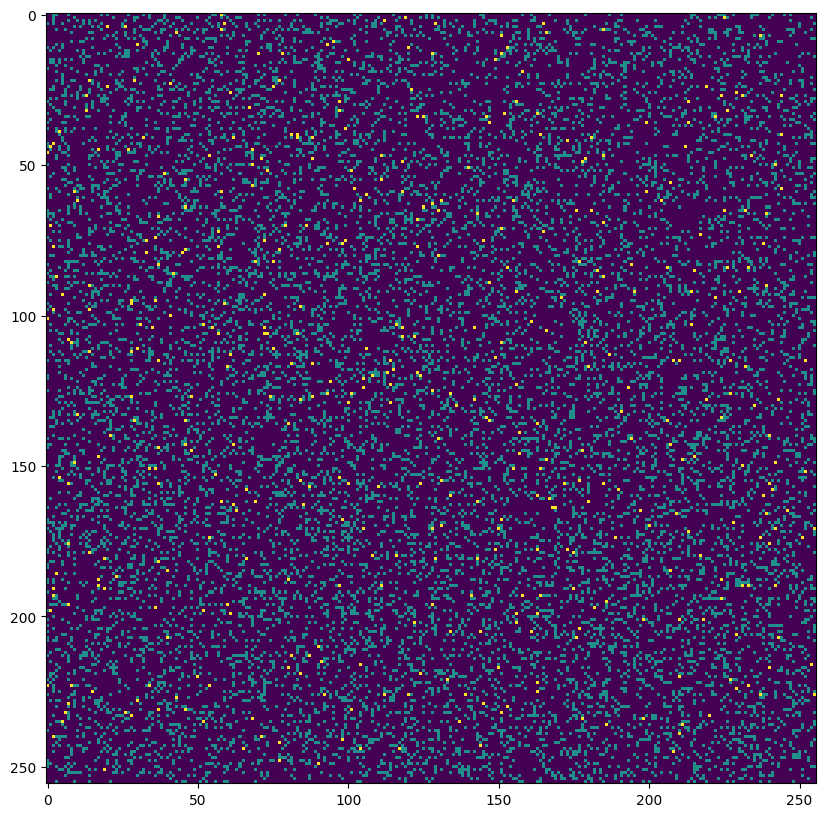

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10,10))
ax.imshow(data[1], cmap='viridis')

MissingBlockError: Missing block "root/filterdata" with index 0

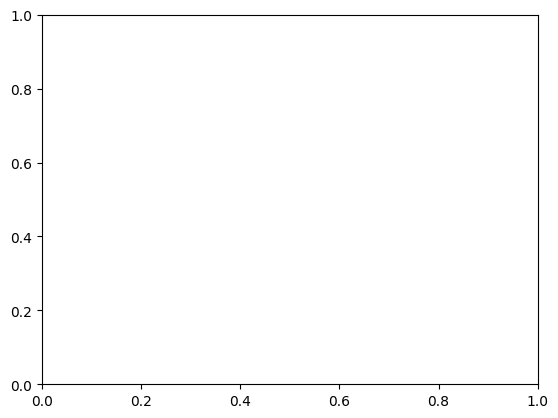